In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lukachitaia/test-for-model/processed_test_ids.csv
/kaggle/input/datasets/lukachitaia/test-for-model/processed_test_features.csv


In [8]:

X_test_ready = pd.read_csv("/kaggle/input/datasets/lukachitaia/test-for-model/processed_test_features.csv")
test_ids = pd.read_csv("/kaggle/input/datasets/lukachitaia/test-for-model/processed_test_ids.csv")['Id']

In [10]:
!pip install dagshub mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 76.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 86.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [11]:
import dagshub
dagshub.init(repo_owner='luchit22', repo_name='ML-house-prices-prediction', mlflow=True)


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=50f9fe2c-9cb0-4c63-8d5c-948695bd409c&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=894ef488a8ce06ddcd14afc90d0274343a07b7d8e6d1a93d4460141872c350bc




Output()

Accessing as luchit22

Initialized MLflow to track repo "luchit22/ML-house-prices-prediction"

Repository luchit22/ML-house-prices-prediction initialized!

In [12]:
import mlflow.sklearn

model_name = "House_Prices_Best_Model"
model_version = 1
loaded_model = mlflow.sklearn.load_model(f"models:/{model_name}/{model_version}")

log_predictions = loaded_model.predict(X_test_ready)
actual_prices = np.expm1(log_predictions)
submission = pd.DataFrame({
    'Id': test_ids, 
    'SalePrice': actual_prices
})

submission.to_csv('submission.csv', index=False)

In [14]:
submission


,Id,SalePrice
0,1461,119678.872735
1,1462,149082.392443
2,1463,173441.177783
3,1464,196875.889983
4,1465,184264.384480
...,...,...
1454,2915,88966.214943
1455,2916,84152.669993
1456,2917,153390.493385
1457,2918,113313.003544


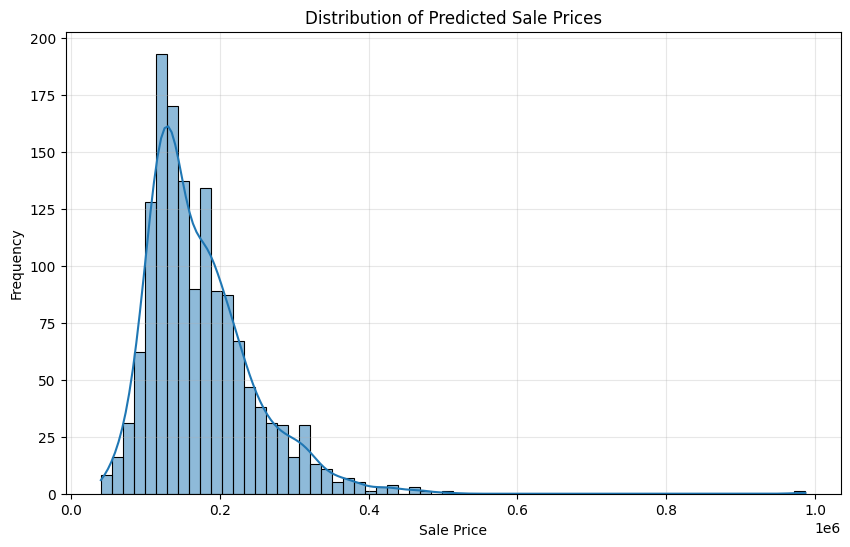

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(submission['SalePrice'], kde=True)
plt.title('Distribution of Predicted Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()